## 1) Setup And Load Labels
Install required packages, import core libraries, and load the labels file used throughout training.

In [ ]:
%pip install kagglehub
%pip install tensorflow pillow
import pandas as pd
import tensorflow as tf
from pathlib import Path

print("TensorFlow version:", tf.__version__)
df = pd.read_csv("dataset/labels.csv")
df.columns = df.columns.str.strip()
print(df.head())
print("Columns:", df.columns.tolist())

## MODEL SPECIFICATIONS
## Hyperparameters: learning_rate = 1e-4, epochs = 80, batch_size = 32
## Input size: 320x320 RGB
## Model: ResNet50 (ImageNet, include_top=False) backbone frozen; trainable classifier head for binary classification (hemorrhage vs no hemorrhage)
## Data augmentation: mild RandomRotation(0.03), RandomZoom(0.05), RandomContrast(0.05)
## Normalization/preprocessing: images scaled to [0, 1], then mapped to 0-255 and passed through resnet50 preprocess_input
## Training metrics: accuracy, AUC, precision, recall
## Extra evaluation: threshold scan with precision, recall, F1, specificity, Youden's J; confusion matrix and classification report


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
TensorFlow version: 2.21.0
   id  hemorrhage
0   0           1
1   1           1
2   2           1
3   3           1
4   4           1
Columns: ['id', 'hemorrhage']


## 2) Resize Raw CT Images
Find the source image folder and resize all CT PNG files to 320x320 for model input consistency.

In [52]:
from pathlib import Path
from PIL import Image

candidate_dirs = [Path("dataset/head_ct"), Path("dataset/head_ct/head_ct")]
src_dir = next((d for d in candidate_dirs if d.exists() and any(d.glob("*.png"))), None)
if src_dir is None:
    raise FileNotFoundError("No PNG files found in dataset/head_ct or dataset/head_ct/head_ct")

dst_dir = Path("dataset/head_ct_320")
dst_dir.mkdir(parents=True, exist_ok=True)

target_size = (320, 320)
count = 0

for img_path in src_dir.glob("*.png"):
    with Image.open(img_path) as img:
        img = img.convert("RGB").resize(target_size, Image.Resampling.LANCZOS)
        img.save(dst_dir / img_path.name, format="PNG", optimize=True)
    count += 1

print(f"Source: {src_dir}")
print(f"Resized {count} images to {target_size} in {dst_dir}")

Source: dataset\head_ct\head_ct
Resized 200 images to (320, 320) in dataset\head_ct_320


## 3) Build Image Path Mapping
Create the image path column in the labels dataframe by matching each ID to its zero-padded PNG filename.

In [53]:
import os

image_dir = "dataset/head_ct_320"

# Filenames are zero-padded (e.g., 000.png), so align id -> filename mapping.
df["image_path"] = df["id"].apply(lambda x: os.path.join(image_dir, f"{int(x):03d}.png"))

## 4) Define Data Generator Class
Define a custom Keras Sequence to load batches, apply mild augmentation, and return image-label tensors.

In [54]:
import numpy as np
import tensorflow as tf
from PIL import Image

class HeadCTDataset(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, target_size=(224, 224), shuffle=True, augment=False, label_col="hemorrhage"):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.augment = augment
        self.label_col = label_col
        self.indices = np.arange(len(self.df))

        if self.label_col not in self.df.columns:
            raise ValueError(f"Label column '{self.label_col}' not found. Available columns: {self.df.columns.tolist()}")

        # Mild augmentation for medical images (avoid aggressive transforms).
        self.augmenter = tf.keras.Sequential([
            tf.keras.layers.RandomRotation(factor=0.03),
            tf.keras.layers.RandomZoom(height_factor=0.05, width_factor=0.05),
            tf.keras.layers.RandomContrast(factor=0.05),
        ])

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_images, batch_labels = [], []

        for i in batch_indices:
            img_path = self.df.iloc[i]["image_path"]
            label = self.df.iloc[i][self.label_col]

            image = Image.open(img_path).convert("RGB").resize(self.target_size)
            image = np.asarray(image, dtype=np.float32) / 255.0

            if self.augment:
                image = tf.convert_to_tensor(image, dtype=tf.float32)
                image = self.augmenter(image, training=True)
                image = tf.clip_by_value(image, 0.0, 1.0).numpy()

            batch_images.append(image)
            batch_labels.append(label)

        return np.array(batch_images, dtype=np.float32), np.array(batch_labels)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

## 5) Split Data And Create Datasets
Perform stratified train/validation/test splitting and instantiate dataset loaders for each split.

In [55]:
from sklearn.model_selection import train_test_split

label_col = "hemorrhage"
batch_size = 32
img_size = 320

# 70% train, 15% val, 15% test (stratified).
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df[label_col]
    if label_col in df.columns and df[label_col].nunique() > 1
    else None,
    shuffle=True,
    )

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df[label_col]
    if label_col in temp_df.columns and temp_df[label_col].nunique() > 1
    else None,
    shuffle=True,
    )

train_dataset = HeadCTDataset(train_df, batch_size=batch_size, target_size=(img_size, img_size), shuffle=True, augment=True, label_col=label_col)
val_dataset = HeadCTDataset(val_df, batch_size=batch_size, target_size=(img_size, img_size), shuffle=False, augment=False, label_col=label_col)
test_dataset = HeadCTDataset(test_df, batch_size=batch_size, target_size=(img_size, img_size), shuffle=False, augment=False, label_col=label_col)

print(f"Total: {len(df)}")
print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df):.1%})")
print(f"Image size: {img_size}x{img_size}")

x_batch, y_batch = train_dataset[0]
print("Train batch shape:", x_batch.shape)
print("Pixel range:", x_batch.min(), x_batch.max())

Total: 200
Train: 140 (70.0%)
Val:   30 (15.0%)
Test:  30 (15.0%)
Image size: 320x320
Train batch shape: (32, 320, 320, 3)
Pixel range: 0.0 1.0


## 6) Build ResNet50 Transfer Model
Create the frozen ResNet50 backbone, attach a binary classification head, and compile with training metrics.

In [56]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

input_shape = (img_size, img_size, 3)

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
base_model.trainable = False  # Freeze pre-trained convolutional backbone.

inputs = layers.Input(shape=input_shape)
x = layers.Lambda(lambda t: t * 255.0)(inputs)  # Convert back to 0-255 for ResNet preprocessing.
x = layers.Lambda(preprocess_input)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs, name="resnet50_transfer_binary")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # learning rate for fine-tuning
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

model.summary()

Model: "resnet50_transfer_binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_8 (Lambda)               │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_9 (Lambda)               │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 10, 10, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 7) Train Model And Evaluate Test Set
Train with early stopping and learning-rate scheduling, then evaluate performance on the held-out test split.

In [57]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", patience=4, mode="max", restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
    ),
]

epochs = 80
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1,
    )

test_metrics = model.evaluate(test_dataset, verbose=1, return_dict=True)
print("Test metrics:", test_metrics)

c:\Users\atill\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.4643 - auc: 0.3844 - loss: 0.9749 - precision: 0.4194 - recall: 0.1857 - val_accuracy: 0.2333 - val_auc: 0.2333 - val_loss: 0.9257 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5143 - auc: 0.5004 - loss: 0.8263 - precision: 0.5208 - recall: 0.3571 - val_accuracy: 0.3000 - val_auc: 0.2378 - val_loss: 0.8952 - val_precision: 0.2857 - val_recall: 0.2667 - learning_rate: 1.0000e-04
Epoch 3/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4571 - auc: 0.4613 - loss: 0.8464 - precision: 0.4483 - recall: 0.3714 - val_accuracy: 0.4333 - val_auc: 0.2511 - val_loss: 0.8792 - val_precision: 0.4444 - val_recall: 0.5333 - learning_rate: 1.0000e-04
Epoch 4/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.4857 - auc: 0.4876 - loss: 0.8072 - precision: 0.4853 - recall: 0.4714 - val_accuracy: 0.4333 - val_auc: 0.2778 - val_loss: 0.8694 -

## 8) Report Best Epoch Metrics
Extract and print the best validation epoch and compare it with final test metrics.

In [58]:
best_epoch = int(np.argmax(history.history["val_auc"]))
print("Best epoch:", best_epoch + 1)
print("Best val_auc:", float(history.history["val_auc"][best_epoch]))
print("Best val_accuracy:", float(history.history["val_accuracy"][best_epoch]))
print("Final test metrics:", test_metrics)

Best epoch: 63
Best val_auc: 0.9200000166893005
Best val_accuracy: 0.8333333134651184
Final test metrics: {'accuracy': 0.8666666746139526, 'auc': 0.9711110591888428, 'loss': 0.3911947011947632, 'precision': 0.8235294222831726, 'recall': 0.9333333373069763}


## 9) Plot Learning Curves
Visualize training versus validation trends for loss, accuracy, and AUC across epochs.

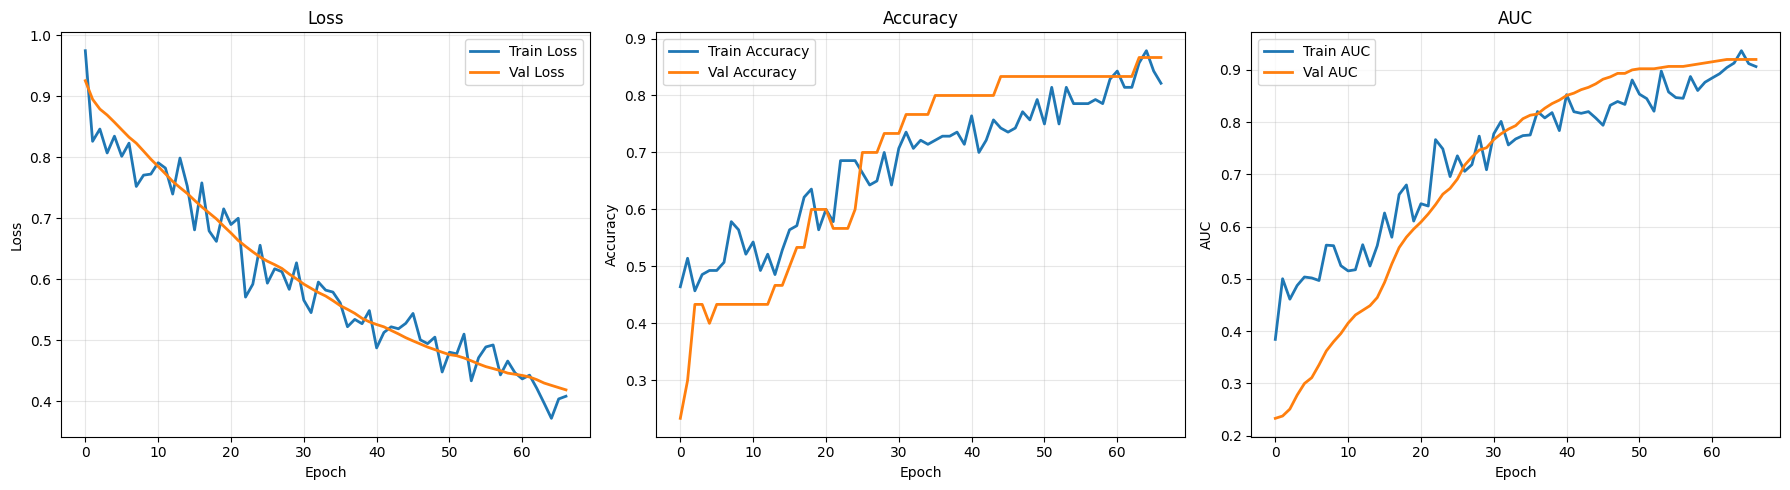

In [59]:
import matplotlib.pyplot as plt

metrics_to_plot = [
    ("loss", "Loss"),
    ("accuracy", "Accuracy"),
    ("auc", "AUC"),
]

plt.figure(figsize=(18, 5))
for i, (metric_key, metric_title) in enumerate(metrics_to_plot, start=1):
    plt.subplot(1, 3, i)
    plt.plot(history.history[metric_key], label=f"Train {metric_title}", linewidth=2)
    plt.plot(history.history[f"val_{metric_key}"], label=f"Val {metric_title}", linewidth=2)
    plt.title(metric_title)
    plt.xlabel("Epoch")
    plt.ylabel(metric_title)
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

## 10) Scan Decision Thresholds
Evaluate multiple probability thresholds and summarize the best operating points by recall, F1, and Youden J.

In [60]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Get probabilities on test set (positive class).
y_true = test_df[label_col].astype(int).to_numpy()
y_prob = model.predict(test_dataset, verbose=0).ravel()

thresholds = np.arange(0.01, 1.00, 0.01)
rows = []
for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    youden_j = recall + specificity - 1.0
    rows.append([t, precision, recall, f1, specificity, youden_j, tn, fp, fn, tp])

scan_df = pd.DataFrame(
    rows,
    columns=[
        "threshold", "precision", "recall", "f1", "specificity", "youden_j",
        "tn", "fp", "fn", "tp"
    ],
)

best_recall_row = scan_df.sort_values(["recall", "f1", "precision"], ascending=False).iloc[0]
best_f1_row = scan_df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
best_youden_row = scan_df.sort_values(["youden_j", "recall", "precision"], ascending=False).iloc[0]

summary_df = pd.DataFrame(
    [
        ["Best Recall", best_recall_row["threshold"], best_recall_row["precision"], best_recall_row["recall"], best_recall_row["f1"], best_recall_row["youden_j"]],
        ["Best F1", best_f1_row["threshold"], best_f1_row["precision"], best_f1_row["recall"], best_f1_row["f1"], best_f1_row["youden_j"]],
        ["Best Youden J", best_youden_row["threshold"], best_youden_row["precision"], best_youden_row["recall"], best_youden_row["f1"], best_youden_row["youden_j"]],
    ],
    columns=["criterion", "threshold", "precision", "recall", "f1", "youden_j"],
)

print("Threshold scan summary:")
display(summary_df.round(4))

print("Top 10 thresholds by F1:")
display(scan_df.sort_values("f1", ascending=False).head(10).round(4))

Threshold scan summary:


,criterion,threshold,precision,recall,f1,youden_j
0,Best Recall,0.46,0.8333,1.0,0.9091,0.8
1,Best F1,0.46,0.8333,1.0,0.9091,0.8
2,Best Youden J,0.46,0.8333,1.0,0.9091,0.8


Top 10 thresholds by F1:


,threshold,precision,recall,f1,specificity,youden_j,tn,fp,fn,tp
45,0.46,0.8333,1.0000,0.9091,0.8000,0.8,12,3,0,15
48,0.49,0.8333,1.0000,0.9091,0.8000,0.8,12,3,0,15
47,0.48,0.8333,1.0000,0.9091,0.8000,0.8,12,3,0,15
46,0.47,0.8333,1.0000,0.9091,0.8000,0.8,12,3,0,15
62,0.63,0.9286,0.8667,0.8966,0.9333,0.8,14,1,2,13
61,0.62,0.9286,0.8667,0.8966,0.9333,0.8,14,1,2,13
60,0.61,0.9286,0.8667,0.8966,0.9333,0.8,14,1,2,13
63,0.64,0.9286,0.8667,0.8966,0.9333,0.8,14,1,2,13
67,0.68,1.0000,0.8000,0.8889,1.0000,0.8,15,0,3,12
69,0.70,1.0000,0.8000,0.8889,1.0000,0.8,15,0,3,12


## 11) Final Threshold And Clinical Metrics
Apply the chosen threshold, compute confusion matrix and classification report, and print clinical interpretation notes.

Chosen threshold: 0.46 (f1)
TN=12, FP=3, FN=0, TP=15
Precision=0.8333 | Recall=1.0000 | Specificity=0.8000 | F1=0.9091

Classification report:
               precision    recall  f1-score   support

No Hemorrhage     1.0000    0.8000    0.8889        15
   Hemorrhage     0.8333    1.0000    0.9091        15

     accuracy                         0.9000        30
    macro avg     0.9167    0.9000    0.8990        30
 weighted avg     0.9167    0.9000    0.8990        30



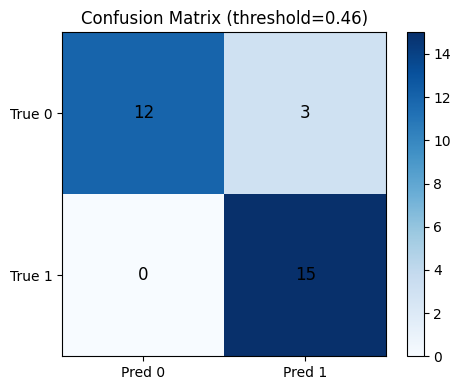

Clinical interpretation:
- Missed hemorrhage cases (FN): 0
- False alarms (FP): 3
- If missing hemorrhage is more critical, prefer recall-oriented threshold.


In [61]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Choose threshold policy: "f1", "recall", "youden", or set a manual float like 0.33
threshold_policy = "f1"
if threshold_policy == "f1":
    chosen_threshold = float(best_f1_row["threshold"])
elif threshold_policy == "recall":
    chosen_threshold = float(best_recall_row["threshold"])
elif threshold_policy == "youden":
    chosen_threshold = float(best_youden_row["threshold"])
else:
    chosen_threshold = float(threshold_policy)

y_pred_final = (y_prob >= chosen_threshold).astype(int)
cm = confusion_matrix(y_true, y_pred_final)
tn, fp, fn, tp = cm.ravel()

precision_final = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall_final = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_final = tn / (tn + fp) if (tn + fp) > 0 else 0.0
f1_final = 2 * precision_final * recall_final / (precision_final + recall_final) if (precision_final + recall_final) > 0 else 0.0

print(f"Chosen threshold: {chosen_threshold:.2f} ({threshold_policy})")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Precision={precision_final:.4f} | Recall={recall_final:.4f} | Specificity={specificity_final:.4f} | F1={f1_final:.4f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred_final, target_names=["No Hemorrhage", "Hemorrhage"], digits=4, zero_division=0))

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix (threshold={chosen_threshold:.2f})")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=12)
plt.tight_layout()
plt.show()

print("Clinical interpretation:")
print(f"- Missed hemorrhage cases (FN): {fn}")
print(f"- False alarms (FP): {fp}")
print("- If missing hemorrhage is more critical, prefer recall-oriented threshold.")

## 12) Export And Reload The Trained Model
Save the trained Keras model to the exports folder and reload it to verify serialization works correctly.

In [67]:
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

export_dir = Path("exports")
export_dir.mkdir(parents=True, exist_ok=True)

model_path = export_dir / "head_ct_resnet50_v1.keras"
model.save(model_path)

print(f"Saved model to: {model_path.resolve()}")
print(f"File size: {model_path.stat().st_size / (1024 * 1024):.2f} MB")

# Your model contains Lambda and preprocess_input references.
loaded_model = tf.keras.models.load_model(
    model_path,
    safe_mode=False,
    custom_objects={"preprocess_input": preprocess_input},
)
print("Reload successful:", isinstance(loaded_model, tf.keras.Model))

Saved model to: C:\Users\atill\OneDrive\Masaüstü\dl project data process\exports\head_ct_resnet50_v1.keras
File size: 90.64 MB
Reload successful: True
